# Learning

In the previous sections, we discussed the static parts of Neural Networks: how to set up the network connectivity, the data, and the loss function.

This section focuses on the dynamics of Neural Networks. In other words, it explains the process of learning the parameters and finding good hyperparameters.

---

## Gradient Checks

In theory, performing a gradient check is as simple as comparing the analytical gradient with the numerical gradient.

In practice, however, the process is much more involved and error-prone. Below are several tips, tricks, and common issues to watch out for.

---

### Use the Centered Formula

The finite difference approximation that is often introduced for evaluating the numerical gradient is:

$$
\frac{df(x)}{dx} = \frac{f(x+h) - f(x)}{h}
$$

**Bad: do not use this formula.**

Here, $h$ is a very small number, usually around $10^{-5}$ in practice.

Instead, it is much better to use the **centered difference formula**:

$$
\frac{df(x)}{dx} = \frac{f(x+h) - f(x-h)}{2h}
$$

**Use this formula instead.**

This method requires evaluating the loss function twice for every single dimension of the gradient, so it is approximately twice as expensive. However, the gradient approximation is much more precise.

Using the Taylor expansion of $f(x+h)$ and $f(x-h)$, we can verify that the first formula has an error on the order of:

$$
O(h)
$$

while the centered formula has error terms on the order of:

$$
O(h^2)
$$

This means the centered formula is a **second-order approximation**.

---

### Use Relative Error for Comparison

When comparing the numerical gradient $f'_n$ and the analytical gradient $f'_a$, we need a reliable way to determine whether they are compatible.

A simple approach would be to track the absolute difference:

$$
|f'_a - f'_n|
$$

or its square, and then define the gradient check as failed if the difference is above some threshold.

However, this is problematic.

For example, suppose the difference is:

$$
10^{-4}
$$

This may be acceptable if both gradients are approximately:

$$
1.0
$$

In that case, the two gradients can be considered a match.

However, if both gradients are on the order of:

$$
10^{-5}
$$

or smaller, then a difference of $10^{-4}$ would be very large and likely indicate a failure.

Therefore, it is more appropriate to use the **relative error**:

$$
\frac{|f'_a - f'_n|}{\max(|f'_a|, |f'_n|)}
$$

This compares the difference between the gradients relative to their magnitude.

Usually, the relative error formula only includes one of the two gradient magnitudes in the denominator. However, using the maximum of both makes the formula symmetric and helps prevent division by zero when one of the gradients is zero, which often happens with ReLU activations.

One special case must still be handled explicitly: if both gradients are zero, the gradient check should pass.

---

### Interpreting Relative Error

In practice, the following rules of thumb are useful:

- If the relative error is greater than $10^{-2}$, the gradient is usually wrong.
- If the relative error is between $10^{-2}$ and $10^{-4}$, you should be concerned.
- If the relative error is less than $10^{-4}$, it is usually acceptable for objectives with kinks.
- If there are no kinks, for example when using `tanh` nonlinearities and softmax, then $10^{-4}$ is still too high.
- If the relative error is around $10^{-7}$ or smaller, the gradient check is very good.

Also remember that deeper networks usually produce higher relative errors.

For example, if you are gradient checking the input data for a 10-layer network, a relative error of:

$$
10^{-2}
$$

might be acceptable because errors accumulate through the layers.

On the other hand, a relative error of $10^{-2}$ for a single differentiable function likely indicates an incorrect gradient.

---

### Use Double Precision

A common pitfall is using single-precision floating point numbers during gradient checking.

Even with a correct gradient implementation, single precision can produce high relative errors, sometimes as large as:

$$
10^{-2}
$$

In practice, switching to double precision can significantly reduce the relative error. For example, relative errors may drop from:

$$
10^{-2}
$$

to:

$$
10^{-8}
$$

just by using double precision.

---

### Stay Within the Active Range of Floating Point Numbers

It is useful to understand floating-point arithmetic, since it can explain many numerical issues during gradient checking.

In Neural Networks, the loss function is often normalized over the batch. However, if the gradients for each data point are already very small, dividing them again by the number of data points can make them extremely small.

This can lead to numerical precision problems.

For this reason, it is useful to print both the raw numerical gradient and the analytical gradient. Make sure the values being compared are not extremely small.

For example, values around:

$$
10^{-10}
$$

or smaller in absolute value are concerning.

If the values are too small, you can temporarily scale the loss function by a constant to move the gradients into a more numerically stable range.

Ideally, the values should be around:

$$
1.0
$$

where floating point numbers are represented more densely.

---

### Kinks in the Objective Function

One important source of inaccuracy during gradient checking is the presence of **kinks**.

Kinks are non-differentiable points in the objective function. They can be introduced by functions such as:

- ReLU:

$$
\max(0, x)
$$

- SVM loss
- Maxout neurons

Consider gradient checking the ReLU function at:

$$
x = -10^{-6}
$$

Since:

$$
x < 0
$$

the analytical gradient at this point is exactly zero.

However, the numerical gradient may become non-zero if:

$$
f(x+h)
$$

crosses the kink. For example, this can happen when:

$$
h > 10^{-6}
$$

In that case, the numerical gradient introduces a non-zero contribution.

This may seem like a rare case, but it is actually common.

For example, an SVM for CIFAR-10 contains up to:

$$
50{,}000 \times 9 = 450{,}000
$$

terms of the form:

$$
\max(0, x)
$$

This happens because there are 50,000 training examples, and each example produces 9 terms in the objective.

A Neural Network with an SVM classifier can contain even more kinks due to ReLU activations.

---

### Detecting Crossed Kinks

It is possible to detect whether a kink was crossed during the loss evaluation.

This can be done by tracking the identities of all “winners” in functions of the form:

$$
\max(x, y)
$$

In other words, we track whether $x$ or $y$ was larger during the forward pass.

If the identity of at least one winner changes when evaluating:

$$
f(x+h)
$$

and:

$$
f(x-h)
$$

then a kink was crossed.

In this case, the numerical gradient will not be exact.

---

### Use Only a Few Data Points

One way to reduce problems caused by kinks is to use fewer data points.

Loss functions with kinks, such as those involving ReLU activations or margin losses, will have fewer kinks when fewer data points are used.

Therefore, it becomes less likely that the finite difference approximation will cross a kink.

Additionally, if the gradient check works for only about 2 or 3 data points, it will almost certainly work for the full batch.

Using very few data points also makes gradient checking faster and more efficient.

---

### Be Careful with the Step Size $h$

A smaller value of $h$ is not always better.

If $h$ is too small, numerical precision problems may occur.

Sometimes, when the gradient check fails, changing $h$ to:

$$
10^{-4}
$$

or:

$$
10^{-6}
$$

can make the gradient check succeed.

The choice of $h$ requires balance:

- If $h$ is too large, the finite difference approximation becomes inaccurate.
- If $h$ is too small, floating-point precision errors become significant.

---

### Perform Gradient Checking in a Characteristic Mode of Operation

A gradient check is performed at a single point in parameter space, usually a random point.

Even if the gradient check succeeds at that point, it does not guarantee that the gradient is implemented correctly everywhere.

A random initialization may not represent a typical or “characteristic” point in parameter space.

For example, an SVM with very small weight initialization will assign nearly zero scores to all data points. In this case, the gradients may show a particular pattern across all data points.

An incorrect gradient implementation might still produce this same pattern and pass the gradient check. However, it may fail later when the network reaches a more characteristic state, where some scores are larger than others.

To reduce this risk, it is better to allow the network to train for a short burn-in period before performing the gradient check.

The gradient check should be performed after the loss has started to decrease.

Performing the gradient check at the very first iteration can introduce pathological edge cases and may hide an incorrect gradient implementation.

---

### Do Not Let Regularization Overwhelm the Data Loss

A loss function is often the sum of two parts:

$$
L = L_{\text{data}} + L_{\text{reg}}
$$

where:

- $L_{\text{data}}$ is the data loss
- $L_{\text{reg}}$ is the regularization loss

For example, the regularization loss may be an L2 penalty on the weights.

One danger is that the regularization loss may overwhelm the data loss. In that case, most of the gradient comes from the regularization term.

This is problematic because the regularization gradient is usually much simpler than the data loss gradient. As a result, an incorrect implementation of the data loss gradient may be hidden.

A good strategy is:

1. Turn off regularization and check the data loss gradient alone.
2. Then check the regularization term separately.

To check the regularization term independently, you can either:

- temporarily remove the data loss contribution from the code, or
- increase the regularization strength so that its effect is clearly visible during gradient checking.

---

### Turn Off Dropout and Data Augmentations

When performing gradient checking, turn off non-deterministic effects such as:

- dropout
- random data augmentations
- other random operations

Otherwise, these effects can introduce large errors when estimating the numerical gradient.

However, turning off these effects means that you are not gradient checking them. For example, dropout might still be backpropagated incorrectly.

A better solution is to force a fixed random seed before each of the following evaluations:

$$
f(x+h)
$$

$$
f(x-h)
$$

and the analytical gradient.

This ensures that the same random choices are made each time.

---

### Check Only a Few Dimensions

In practice, gradients may contain millions of parameters.

Therefore, it is usually only practical to check a small number of dimensions and assume the others are correct.

However, be careful.

You should make sure to gradient check a few dimensions for every separate parameter group.

In some applications, all parameters are combined into a single large vector for convenience. In such cases, bias parameters may occupy only a very small part of the full vector.

If dimensions are sampled completely at random, it is possible that some parameter groups, such as biases, are never checked.

Therefore, make sure that all parameter groups receive correct gradients.

---

## Summary

Gradient checking is a powerful debugging tool, but it must be used carefully.

Important practices include:

- using the centered difference formula,
- comparing gradients with relative error,
- using double precision,
- avoiding extremely small gradient values,
- being aware of kinks,
- using only a few data points,
- choosing the step size $h$ carefully,
- performing checks after a short burn-in period,
- testing data loss and regularization separately,
- disabling or controlling randomness,
- and checking dimensions from every parameter group.

## Before Learning: Sanity Checks and Tips/Tricks

Before starting expensive optimization, it is useful to run a few sanity checks.

These checks can help detect implementation mistakes early, before spending significant time training the model.

---

### Check for the Correct Loss at Chance Performance

Make sure the loss has the expected value when the model is initialized with small random parameters.

It is best to check the **data loss alone** first, so the regularization strength should be set to zero.

For example, with CIFAR-10 and a Softmax classifier, the initial loss should be approximately:

$$
2.302
$$

This is because CIFAR-10 has 10 classes, so at initialization we expect a diffuse probability of:

$$
0.1
$$

for each class.

The Softmax loss is the negative log probability of the correct class:

$$
-\ln(0.1) = 2.302
$$

Therefore, the expected initial Softmax loss is:

$$
2.302
$$

For the Weston-Watkins SVM loss, we expect all desired margins to be violated because all scores are approximately zero at initialization.

Since CIFAR-10 has 10 classes, there are 9 incorrect classes for each example. If the margin is 1 for each wrong class, the expected loss is:

$$
9
$$

If you do not observe these expected losses, there may be a problem with the initialization or loss implementation.

---

### Increase Regularization Strength

As a second sanity check, increasing the regularization strength should increase the loss.

This is expected because the total loss often includes both data loss and regularization loss:

$$
L = L_{\text{data}} + L_{\text{reg}}
$$

If the regularization strength increases, the regularization term should usually become larger.

---

### Overfit a Tiny Subset of Data

The most important sanity check is to train the model on a very small portion of the data, for example:

$$
20
$$

examples.

Before training on the full dataset, make sure the model can overfit this tiny subset and achieve nearly zero cost.

For this experiment, it is best to set regularization to zero:

$$
\lambda = 0
$$

Otherwise, regularization may prevent the model from reaching zero cost.

If the model cannot overfit a tiny dataset, it is not worth proceeding to the full dataset.

However, passing this sanity check does not guarantee that the implementation is fully correct.

For example, if the data features are random because of a bug, the model may still overfit a tiny training set. However, it will fail to generalize when trained on the full dataset.

---

## Babysitting the Learning Process

During Neural Network training, there are several useful quantities that should be monitored.

These plots act as a window into the training process. They help build intuition about different hyperparameter settings and how those settings should be changed for more efficient learning.

The x-axis of the plots is usually measured in **epochs**.

An epoch measures how many times each training example has been seen in expectation.

For example, one epoch means that every example has been seen once on average.

Tracking epochs is preferable to tracking iterations because the number of iterations depends on the batch size, which is an arbitrary setting.

---

## Loss Function
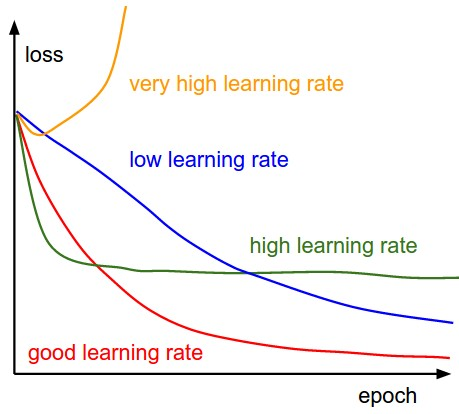
The first quantity to track during training is the loss.

The loss is evaluated on individual batches during the forward pass.

A loss curve can provide important information about the learning rate.

---

### Interpreting the Loss Curve

With a low learning rate, improvements in the loss may look approximately linear.

With a higher learning rate, the loss may decrease more quickly and appear more exponential.

However, if the learning rate is too high, the loss may decrease quickly at first but then get stuck at a worse value.

This happens because the optimization has too much “energy.” The parameters bounce around chaotically and cannot settle into a good region of the optimization landscape.

A reasonable loss curve should decrease over time.

If the loss decreases too slowly, the learning rate may be too small.

If the loss is very noisy, the batch size may be too small.

---

### Wiggle in the Loss Curve

The amount of “wiggle” or noise in the loss curve is related to the batch size.

When the batch size is:

$$
1
$$

the wiggle is usually high.

When the batch size is the full dataset, the wiggle is minimal because each gradient update is computed using all training examples.

In that case, the loss should generally improve more smoothly, unless the learning rate is too high.

---

### Plotting Loss in the Log Domain

Some people prefer to plot the loss function in the log domain.

Learning progress often has an approximately exponential shape.

As a result, plotting the loss in the log domain can make the curve look more like a straight line instead of a hockey-stick shape.

This can make the training process easier to interpret.

Additionally, when multiple cross-validated models are plotted on the same loss graph, differences between them may become easier to see.

---

## Train/Validation Accuracy

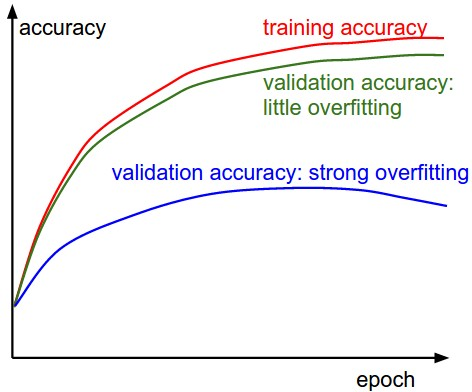

The second important quantity to track during classifier training is the training and validation accuracy.

This plot provides useful information about overfitting.

---

### Interpreting the Accuracy Gap

The gap between training accuracy and validation accuracy indicates the amount of overfitting.

If the training accuracy is much higher than the validation accuracy, the model is overfitting.

In this case, the validation accuracy may even start decreasing after some point.

When this happens, possible solutions include:

- increasing regularization,
- using a stronger L2 weight penalty,
- using more dropout,
- collecting more data.

If the validation accuracy follows the training accuracy closely, the model may not have enough capacity.

In that case, the model may be too small.

A possible solution is to increase the model size by adding more parameters.

---

## Ratio of Weights to Updates

Another useful quantity to monitor is the ratio of update magnitudes to parameter value magnitudes.

This should be computed using the **updates**, not the raw gradients.

For example, in vanilla SGD, the update is the gradient multiplied by the learning rate.

You may want to track this ratio independently for every parameter group.

A rough heuristic is that this ratio should be around:

$$
10^{-3}
$$

If the ratio is much lower than this, the learning rate may be too low.

If the ratio is much higher than this, the learning rate is likely too high.




## Parameter Updates

Once the analytical gradient has been computed using backpropagation, the gradients are used to update the parameters.

There are several approaches for performing parameter updates. These methods differ in how they use gradients, learning rates, momentum, and adaptive scaling.

Optimization for deep networks is still an active research area. This section focuses on common and established techniques used in practice, together with their main intuitions.

---

## SGD and Its Variants

### Vanilla SGD Update

The simplest parameter update is to move the parameters in the direction of the **negative gradient**.

This is because the gradient points in the direction of greatest increase, while our goal is usually to minimize the loss function.

Given:

- a parameter vector $x$
- its gradient $dx$
- a learning rate $\alpha$

the vanilla SGD update is:

$$
x \leftarrow x - \alpha dx
$$

Here, the learning rate $\alpha$ is a hyperparameter.

When this update is evaluated on the full dataset, and when the learning rate is small enough, it is guaranteed to make non-negative progress on the loss function.

However, in practice, vanilla SGD can be slow, especially for deep neural networks.

---

## Momentum Update

Momentum is an update method that almost always achieves better convergence rates than vanilla SGD in deep networks.

The intuition comes from physics.

We can think of the loss function as the height of a hilly terrain. Since potential energy is given by:

$$
U = mgh
$$

we can say that:

$$
U \propto h
$$

where $h$ is the height of the terrain.

Initializing the parameters randomly is like placing a particle at some random location with zero initial velocity.

The optimization process can then be interpreted as a particle rolling down the loss landscape.

---

### Physical Interpretation of Momentum

The force acting on the particle is related to the negative gradient of the potential energy:

$$
F = -\nabla U
$$

Therefore, the force felt by the particle corresponds to the negative gradient of the loss function.

Using Newton’s second law:

$$
F = ma
$$

the negative gradient can be interpreted as being proportional to the acceleration of the particle.

This is different from vanilla SGD, where the gradient directly changes the position.

In the momentum view, the gradient affects the velocity, and the velocity affects the position.

---

### Momentum Update Formula

The momentum update can be written as:

$$
v \leftarrow \mu v - \alpha dx
$$

$$
x \leftarrow x + v
$$

where:

- $v$ is the velocity,
- $\mu$ is the momentum coefficient,
- $\alpha$ is the learning rate,
- $dx$ is the gradient.

The velocity $v$ is usually initialized to zero.

The hyperparameter $\mu$ is commonly called **momentum**, although physically it behaves more like a friction coefficient.

Typical values for $\mu$ include:

$$
0.5,\ 0.9,\ 0.95,\ 0.99
$$

A common default value is:

$$
\mu = 0.9
$$

Momentum dampens the velocity and reduces the kinetic energy of the system. Without this damping effect, the particle would not stop at the bottom of the loss landscape.

---

### Momentum Scheduling

Momentum can also be scheduled over time.

For example, optimization may benefit from starting with a smaller momentum value and increasing it later during training.

A typical strategy is to start with:

$$
\mu = 0.5
$$

and gradually increase it to:

$$
\mu = 0.99
$$

over several epochs.

With momentum, the parameter vector builds up velocity in directions where the gradient is consistent.

This helps accelerate optimization along stable directions and can reduce unnecessary oscillations.

---

## Nesterov Momentum

Nesterov Momentum is a slightly different version of the standard momentum update.

It has stronger theoretical convergence guarantees for convex functions and often works slightly better than standard momentum in practice.

---

### Main Idea of Nesterov Momentum

In standard momentum, if the current parameter vector is at position $x$, the momentum term alone is about to move it by:

$$
\mu v
$$

Therefore, the approximate future position is:

$$
x + \mu v
$$

Nesterov Momentum uses this future approximate position as a **lookahead point**.

Instead of computing the gradient at the current position $x$, it computes the gradient at:

$$
x + \mu v
$$

This allows the optimizer to look ahead and correct its direction earlier.

---

![Nesterov Momentum Visualization]

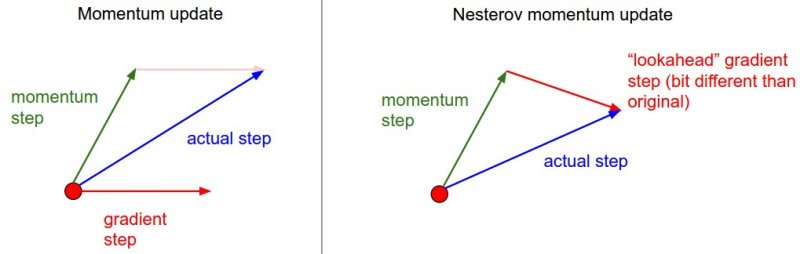

---

### Nesterov Momentum Update

The intuitive form of Nesterov Momentum is:

$$
x_{\text{ahead}} = x + \mu v
$$

Then the gradient is evaluated at $x_{\text{ahead}}$ instead of $x$.

The velocity and position are then updated as:

$$
v \leftarrow \mu v - \alpha dx_{\text{ahead}}
$$

$$
x \leftarrow x + v
$$

where $dx_{\text{ahead}}$ is the gradient evaluated at the lookahead position.

---

### Practical Form of Nesterov Momentum

In practice, the update is often rewritten to look similar to vanilla SGD or standard momentum.

Using a variable transformation, the update can be expressed as:

$$
v_{\text{prev}} \leftarrow v
$$

$$
v \leftarrow \mu v - \alpha dx
$$

$$
x \leftarrow x - \mu v_{\text{prev}} + (1 + \mu)v
$$

This version stores the lookahead parameter vector directly.

---

### Additional References

Recommended references for Nesterov Accelerated Gradient include:

- **Advances in Optimizing Recurrent Networks** by Yoshua Bengio, Section 3.5
- **Ilya Sutskever’s thesis**, Section 7.2

---

## Annealing the Learning Rate

When training deep networks, it is usually helpful to decrease the learning rate over time.

This process is called **learning rate annealing** or **learning rate decay**.

---

### Intuition Behind Learning Rate Decay

With a high learning rate, the optimization process has too much kinetic energy.

The parameter vector may bounce around chaotically and fail to settle into deeper but narrower regions of the loss landscape.

However, deciding when to decay the learning rate is difficult.

If the learning rate decays too slowly, computation is wasted because the parameters keep bouncing around with little improvement.

If the learning rate decays too quickly, the system cools too fast and may fail to reach a good solution.

---

## Common Learning Rate Decay Strategies

### Step Decay

In step decay, the learning rate is reduced by a fixed factor every few epochs.

For example, one might reduce the learning rate by half every 5 epochs:

$$
\alpha \leftarrow \frac{1}{2}\alpha
$$

or reduce it by a factor of $0.1$ every 20 epochs:

$$
\alpha \leftarrow 0.1\alpha
$$

The best values depend heavily on the problem and the model.

A common practical heuristic is to monitor the validation error and reduce the learning rate whenever the validation error stops improving.

For example:

$$
\alpha \leftarrow 0.5\alpha
$$

---

### Exponential Decay

Exponential decay has the form:

$$
\alpha = \alpha_0 e^{-kt}
$$

where:

- $\alpha_0$ is the initial learning rate,
- $k$ is a decay hyperparameter,
- $t$ is the iteration number or epoch number.

---

### Inverse Time Decay

Inverse time decay has the form:

$$
\alpha = \frac{\alpha_0}{1 + kt}
$$

where:

- $\alpha_0$ is the initial learning rate,
- $k$ is a decay hyperparameter,
- $t$ is the iteration number or epoch number.

---

### Practical Recommendation

In practice, step decay is often slightly preferred because its hyperparameters are easier to interpret.

The decay factor and step timing in epochs are usually more intuitive than the hyperparameter $k$ used in exponential or inverse time decay.

If enough computational budget is available, it is usually better to decay the learning rate more slowly and train for a longer time.

---

## Second-Order Methods

Another important family of optimization methods is based on **Newton’s method**.

Newton’s method uses second-order information about the loss function.

The update rule is:

$$
x \leftarrow x - [Hf(x)]^{-1}\nabla f(x)
$$

where:

- $Hf(x)$ is the Hessian matrix,
- $\nabla f(x)$ is the gradient vector.

---

### Hessian Matrix

The Hessian matrix is a square matrix of second-order partial derivatives.

It describes the local curvature of the loss function.

Using curvature information can lead to more efficient updates.

In particular, multiplying by the inverse Hessian allows the optimizer to:

- take larger steps in directions with shallow curvature,
- take smaller steps in directions with steep curvature.

A major theoretical advantage of Newton’s method is that it does not require a learning rate hyperparameter.

---

### Why Newton’s Method Is Impractical for Deep Learning

Although Newton’s method is appealing, it is usually impractical for deep learning.

The reason is that computing and inverting the Hessian matrix is extremely expensive in both memory and computation.

For example, a neural network with one million parameters would have a Hessian matrix of size:

$$
1{,}000{,}000 \times 1{,}000{,}000
$$

This matrix would require approximately:

$$
3725
$$

gigabytes of RAM.

Therefore, explicitly computing the Hessian is not practical for large neural networks.

---

## Quasi-Newton Methods

To avoid the cost of explicitly computing the Hessian, many **quasi-Newton methods** have been developed.

These methods approximate the inverse Hessian instead of computing it directly.

The most popular quasi-Newton method is **L-BFGS**.

L-BFGS uses gradient information collected over time to implicitly approximate the inverse Hessian.

The full Hessian matrix is never explicitly computed.

---

### Limitations of L-BFGS in Deep Learning

Even though L-BFGS reduces memory issues, it has another major drawback.

A naive application of L-BFGS requires evaluating the entire training set.

This becomes difficult when the dataset contains millions of examples.

In contrast, mini-batch SGD works naturally with small batches.

Using L-BFGS with mini-batches is more difficult and remains an active research area.

For this reason, L-BFGS and other second-order methods are not commonly used for large-scale deep learning or convolutional neural networks.

Instead, variants of SGD with momentum, especially Nesterov Momentum, are more common because they are simpler and scale more easily.

---

### Additional References

Useful references on second-order and large-scale optimization include:

- **Large Scale Distributed Deep Networks**, a paper from the Google Brain team comparing L-BFGS and SGD variants in large-scale distributed optimization.
- **SFO algorithm**, which attempts to combine the advantages of SGD and L-BFGS.

---

## Per-Parameter Adaptive Learning Rate Methods

The optimization methods discussed so far use a global learning rate.

This means that the same learning rate is applied to all parameters.

However, tuning the learning rate can be expensive.

For this reason, many methods have been developed to adapt the learning rate automatically, sometimes separately for each parameter.

These methods may still require hyperparameters, but they are often well-behaved across a broader range of settings than a raw global learning rate.

---

## Adagrad

Adagrad is an adaptive learning rate method proposed by Duchi et al.

Adagrad keeps track of the sum of squared gradients for each parameter.

Let the accumulated squared-gradient cache be:

$$
\text{cache} \leftarrow \text{cache} + dx^2
$$

Then the parameter update is:

$$
x \leftarrow x - \alpha \frac{dx}{\sqrt{\text{cache}} + \epsilon}
$$

where:

- $\alpha$ is the learning rate,
- $dx$ is the gradient,
- $\epsilon$ is a small smoothing term.

The cache has the same size as the gradient.

It stores the sum of squared gradients independently for every parameter.

---

### Intuition Behind Adagrad

Parameters that receive large gradients will have their effective learning rate reduced.

Parameters that receive small or infrequent gradients will have their effective learning rate increased.

The square root operation is very important. Without it, the algorithm performs much worse.

The smoothing term $\epsilon$ prevents division by zero.

Typical values for $\epsilon$ are between:

$$
10^{-4}
$$

and:

$$
10^{-8}
$$

A downside of Adagrad is that the learning rate decreases monotonically.

In deep learning, this decrease can be too aggressive and may stop learning too early.

---

## RMSprop

RMSprop is an effective adaptive learning rate method.

It modifies Adagrad to reduce the problem of aggressively decreasing learning rates.

Instead of accumulating all squared gradients forever, RMSprop uses a moving average of squared gradients.

The cache update is:

$$
\text{cache} \leftarrow \rho \cdot \text{cache} + (1 - \rho)dx^2
$$

The parameter update is:

$$
x \leftarrow x - \alpha \frac{dx}{\sqrt{\text{cache}} + \epsilon}
$$

where:

- $\rho$ is the decay rate,
- $\alpha$ is the learning rate,
- $\epsilon$ prevents division by zero.

Typical values for the decay rate are:

$$
0.9,\ 0.99,\ 0.999
$$

---

### Intuition Behind RMSprop

RMSprop still changes the learning rate of each parameter based on the magnitude of its gradients.

However, unlike Adagrad, the cache is “leaky.”

This means old gradients gradually lose influence.

As a result, RMSprop avoids the monotonically decreasing learning rate problem of Adagrad.

This often makes RMSprop more effective for deep learning.

---

## Adam

Adam is an adaptive optimization method that can be viewed as combining ideas from RMSprop and momentum.

It keeps track of:

- a moving average of gradients,
- a moving average of squared gradients.

The simplified Adam update is:

$$
m \leftarrow \beta_1 m + (1 - \beta_1)dx
$$

$$
v \leftarrow \beta_2 v + (1 - \beta_2)dx^2
$$

$$
x \leftarrow x - \alpha \frac{m}{\sqrt{v} + \epsilon}
$$

where:

- $m$ is the moving average of gradients,
- $v$ is the moving average of squared gradients,
- $\beta_1$ controls the decay rate for $m$,
- $\beta_2$ controls the decay rate for $v$,
- $\alpha$ is the learning rate,
- $\epsilon$ prevents division by zero.

Recommended values are:

$$
\epsilon = 10^{-8}
$$

$$
\beta_1 = 0.9
$$

$$
\beta_2 = 0.999
$$

---

### Adam with Bias Correction

In the first few iterations, the moving averages $m$ and $v$ are initialized at zero.

Because of this, they are biased toward zero before they fully warm up.

Adam corrects this bias using bias-corrected estimates.

Let $t$ be the iteration number, starting from:

$$
t = 1
$$

The bias-corrected first moment estimate is:

$$
\hat{m} = \frac{m}{1 - \beta_1^t}
$$

The bias-corrected second moment estimate is:

$$
\hat{v} = \frac{v}{1 - \beta_2^t}
$$

The final Adam update becomes:

$$
x \leftarrow x - \alpha \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
$$

---

### Practical Recommendation

Adam is commonly recommended as a default optimization algorithm.

It often works slightly better than RMSprop.

However, it is also often worth trying SGD with Nesterov Momentum as an alternative.

---

### Additional Reference

A useful reference for stochastic optimization methods is:

- **Unit Tests for Stochastic Optimization**, which proposes a series of standardized benchmark tests for stochastic optimization algorithms.

---

## Optimization Dynamics Visualizations

Visualizations can help build intuition about how different optimization algorithms behave during training.

---

![Optimization Algorithms on a Loss Surface]

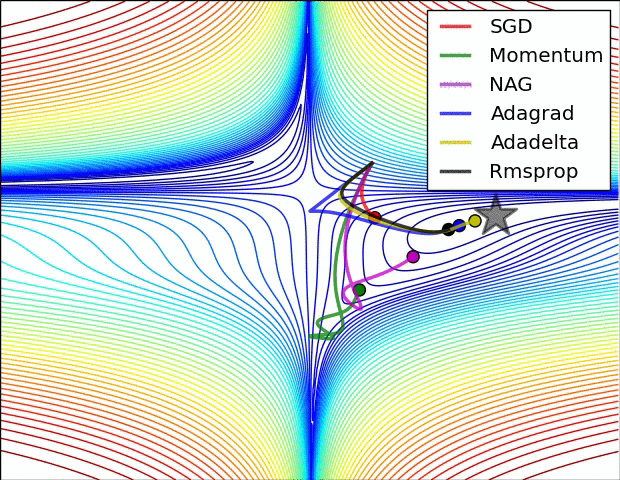

---

The left visualization shows contours of a loss surface and the time evolution of different optimization algorithms.

Momentum-based methods often show an **overshooting** behavior.

This makes the optimization process look like a ball rolling down a hill.

---

![Saddle Point Visualization]

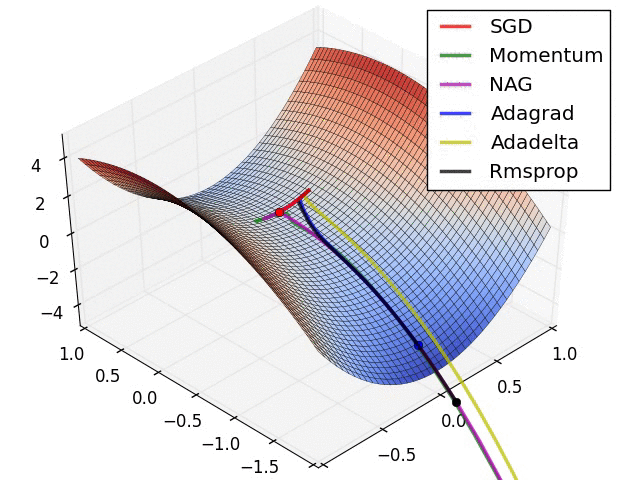

---

The right visualization shows a saddle point in the optimization landscape.

At a saddle point, the curvature has different signs in different dimensions.

For example:

- one dimension curves upward,
- another dimension curves downward.

SGD can have difficulty breaking symmetry and may get stuck near the saddle point.

In contrast, methods such as RMSprop can handle this situation better.

When RMSprop sees very small gradients in the saddle direction, the denominator in the RMSprop update becomes small.

This increases the effective learning rate in that direction and helps RMSprop move forward.

Image credit: Alec Radford.

---

## Summary

Parameter updates are the core mechanism by which neural networks learn.

Important optimization methods include:

- Vanilla SGD,
- Momentum,
- Nesterov Momentum,
- learning rate decay,
- second-order methods,
- L-BFGS,
- Adagrad,
- RMSprop,
- Adam.

In practice, Adam is often a strong default choice.

However, SGD with Nesterov Momentum is also widely used and can sometimes perform better.

Learning rate schedules, momentum, adaptive learning rates, and careful monitoring of optimization dynamics are all important for successful neural network training.

## Hyperparameter Optimization

Training Neural Networks often involves many hyperparameter settings.

The most common hyperparameters in Neural Networks include:

- the initial learning rate,
- the learning rate decay schedule,
- the regularization strength.

Examples of regularization hyperparameters include:

- L2 penalty strength,
- dropout strength.

There are also many less sensitive hyperparameters, such as:

- parameters used in adaptive learning-rate methods,
- momentum,
- momentum schedules.

This section describes practical tips and tricks for performing hyperparameter search.

---

## Implementation

Large Neural Networks often require a long time to train.

As a result, hyperparameter search can take many days or even weeks.

This should be considered when designing the code base.

A common design is to use a **worker** that continuously samples random hyperparameters and performs optimization.

During training, the worker tracks validation performance after every epoch.

It also writes model checkpoints to a file.

These checkpoints should include:

- the model parameters,
- validation performance,
- training loss over time,
- other useful training statistics.

It is useful to include validation performance directly in the checkpoint filename.

This makes it easier to inspect, compare, and sort the results.

A second program, called the **master**, can then be used to manage the workers.

The master may:

- launch workers,
- stop workers,
- manage jobs across a computing cluster,
- inspect checkpoints,
- plot training statistics.

---

## Prefer One Validation Fold to Cross-Validation

In most cases, using a single validation set of respectable size is preferable to full cross-validation.

A single validation set substantially simplifies the code base.

It also avoids the complexity of using multiple cross-validation folds.

In practice, when people say they “cross-validated” a parameter, they often mean that they tuned it using a single validation set.

---

## Hyperparameter Ranges

Hyperparameters such as learning rate and regularization strength should usually be searched on a **log scale**.

For example, a typical learning-rate sampling strategy is:

$$
\text{learning\_rate} = 10^{u}
$$

where:

$$
u \sim \text{Uniform}(-6, 1)
$$

This means the learning rate is sampled from the range:

$$
10^{-6}
$$

to:

$$
10^{1}
$$

The same strategy should be used for regularization strength.

---

### Why Use Log Scale?

Learning rate and regularization strength have multiplicative effects on training dynamics.

For example, adding:

$$
0.01
$$

to a learning rate has a huge effect if the current learning rate is:

$$
0.001
$$

However, adding the same value has almost no effect if the learning rate is:

$$
10
$$

This is because the learning rate multiplies the computed gradient during the parameter update.

Therefore, it is more natural to search over values that multiply or divide the learning rate by some factor, rather than values that add or subtract a fixed amount.

Some hyperparameters are usually searched in the original scale.

For example, dropout may be sampled as:

$$
\text{dropout} \sim \text{Uniform}(0, 1)
$$

---

## Prefer Random Search to Grid Search

Random search is usually preferable to grid search for hyperparameter optimization.

As argued by Bergstra and Bengio in **Random Search for Hyper-Parameter Optimization**, randomly chosen trials are often more efficient than grid-based trials.

Random search is also usually easier to implement.

---

![Random Search vs Grid Search]

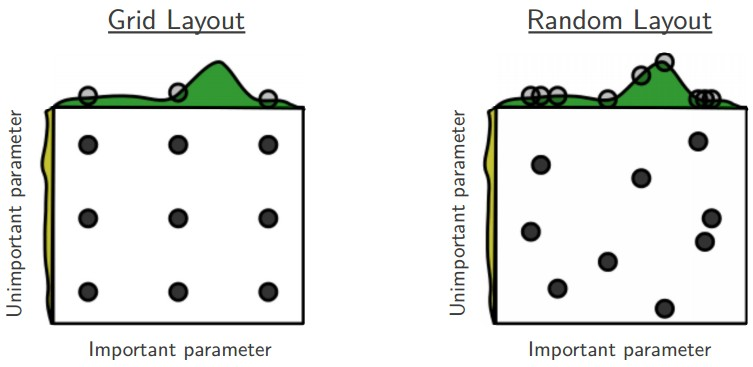

---

The key intuition is that some hyperparameters often matter much more than others.

In grid search, many trials may be wasted exploring unimportant hyperparameters.

Random search explores the space more flexibly.

This gives it a better chance of discovering good values for the important hyperparameters.

---

## Be Careful with Best Values on the Border

Sometimes, the chosen search range for a hyperparameter may be bad.

For example, suppose the learning rate is sampled as:

$$
\text{learning\_rate} = 10^u
$$

where:

$$
u \sim \text{Uniform}(-6, 1)
$$

After collecting results, check whether the best learning rate lies near the edge of the interval.

If the best value is near the boundary, there may be better values outside the searched range.

For example, if the best learning rate is close to:

$$
10^{-6}
$$

then even smaller learning rates may need to be tested.

If the best learning rate is close to:

$$
10^1
$$

then larger learning rates may need to be tested.

---

## Stage the Search from Coarse to Fine

In practice, it is useful to search hyperparameters in stages.

Start with a coarse search over a wide range.

For example:

$$
10^{-6}
$$

to:

$$
10^1
$$

Then, based on where the best results appear, narrow the range and search again.

---

### Example Search Strategy

A practical staged search may look like this:

1. **Coarse search**

   Search over a wide range.

   Train each model for only one epoch or less.

   This helps quickly eliminate hyperparameter settings that do not learn at all or cause the loss to explode.

2. **Medium search**

   Narrow the range based on the best results from the coarse search.

   Train each model for a few epochs, such as:

   $$
   5
   $$

   epochs.

3. **Fine search**

   Search carefully within the final promising range.

   Train each model for many more epochs.

This staged approach saves computation and makes the search more efficient.

---

## Bayesian Hyperparameter Optimization

Bayesian Hyperparameter Optimization is a research area focused on navigating hyperparameter space more efficiently.

The main idea is to balance:

- exploration,
- exploitation.

Exploration means trying uncertain regions of the hyperparameter space.

Exploitation means focusing on regions that already appear promising.

Several libraries have been developed for Bayesian hyperparameter optimization, including:

- Spearmint,
- SMAC,
- Hyperopt.

However, in practical ConvNet settings, it is still difficult to consistently beat random search over carefully chosen intervals.

---

# Evaluation

## Model Ensembles

In practice, one reliable way to improve Neural Network performance by a few percent is to train multiple independent models and average their predictions at test time.

As the number of models in the ensemble increases, performance usually improves monotonically.

However, the gains show diminishing returns.

The improvement is usually larger when the ensemble contains more diverse models.

---

## Approaches to Building an Ensemble

### Same Model, Different Initializations

One approach is to first use validation performance to find the best hyperparameters.

Then, train multiple models using the same best hyperparameters but different random initializations.

The downside is that model diversity comes only from random initialization.

---

### Top Models Found During Hyperparameter Search

Another approach is to select the top models discovered during hyperparameter search.

For example, choose the best:

$$
10
$$

models and combine them into an ensemble.

This approach improves diversity because the models may use different hyperparameters.

However, it may include some suboptimal models.

In practice, this can be convenient because it does not require retraining models after hyperparameter search.

---

### Different Checkpoints of a Single Model

If training is very expensive, another cheap approach is to use different checkpoints of the same model.

For example, one can save a checkpoint after every epoch and use these checkpoints as ensemble members.

This method has less diversity because all checkpoints come from the same training run.

However, it can still work reasonably well in practice.

Its main advantage is that it is very cheap.

---

### Running Average of Parameters During Training

A cheap way to often gain an extra percent or two of performance is to maintain a second copy of the network weights.

This second copy stores an exponentially decaying average of previous weights during training.

In other words, it averages the state of the network over the last several iterations.

This smoothed version of the weights often achieves better validation error.

---

### Intuition Behind Parameter Averaging

A useful intuition is that the objective function may be bowl-shaped near a good solution.

During training, the network parameters may jump around the optimum.

The average of recent parameter values may therefore be closer to the center of the bowl.

As a result, the averaged parameters can sometimes generalize better.

---

## Disadvantage of Model Ensembles

A disadvantage of model ensembles is that they take longer to evaluate on test examples.

This is because multiple models must be evaluated instead of only one.

---

## Dark Knowledge and Model Distillation

An interesting idea proposed by Geoff Hinton is known as **Dark Knowledge**.

The goal is to distill the knowledge of a strong ensemble back into a single model.

This can be done by incorporating the ensemble’s predicted probabilities into a modified training objective.

The result is a single model that tries to imitate the behavior of the ensemble.

This approach can retain some of the ensemble’s performance while reducing test-time computation.

---

## Summary

Hyperparameter optimization is an essential part of training Neural Networks.

Important practical guidelines include:

- search learning rate and regularization strength on a log scale,
- prefer random search over grid search,
- use a single validation set in most cases,
- check whether best values lie near search boundaries,
- stage the search from coarse to fine,
- consider Bayesian optimization, but do not underestimate random search.

For evaluation, model ensembles are a reliable way to improve performance.

Common ensemble strategies include:

- training the same model with different random initializations,
- combining the top models from hyperparameter search,
- using different checkpoints from a single model,
- maintaining a running average of parameters.

Model ensembles improve accuracy but increase test-time computation.

Model distillation can be used to compress the knowledge of an ensemble into a single model.